In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("hosseinbadrnezhad/human-faces-dataset-male-female-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'human-faces-dataset-male-female-classification' dataset.
Path to dataset files: /kaggle/input/human-faces-dataset-male-female-classification
Contents of base_path (/kaggle/input):
['human-faces-dataset-male-female-classification']
Contents of path (/kaggle/input/human-faces-dataset-male-female-classification):
['men', 'women']


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Output path for the split dataset
output_folder = "dataset_split"

# Split the dataset: 80% Train, 20% Val
# If you want 3 parts (Train/Val/Test), change ratio to (.8, .1, .1)
splitfolders.ratio(path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Split completed! New data is located at: {output_folder}")

Copying files: 2000 files [00:24, 82.49 files/s] 

Split completed! New data is located at: dataset_split


In [ ]:
import os

def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if not dirs: # Only print leaf directories
            print(f"{root}: {len(files)} images")

print("Verifying image counts after split:")
count_files(output_folder)

Verifying image counts after split:
dataset_split/val/men: 146 images
dataset_split/val/women: 255 images
dataset_split/train/men: 581 images
dataset_split/train/women: 1018 images


In [ ]:
import tensorflow as tf

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU devices found. Using CPU.")

1 Physical GPUs, 1 Logical GPUs


### Build and Train AlexNet Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
IMAGE_SIZE = (227, 227) # AlexNet input size
BATCH_SIZE = 32
EPOCHS = 10 # You can increase this for better training

# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Load data from the split folders
train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build AlexNet model
model = Sequential([
    Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    BatchNormalization(),
    MaxPooling2D((3, 3), strides=(2, 2)),

    Conv2D(256, (5, 5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((3, 3), strides=(2, 2)),

    Conv2D(384, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(384, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((3, 3), strides=(2, 2)),

    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

Found 1599 images belonging to 2 classes.
Found 401 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,295,042 (222.38 MB)

 Trainable params: 58,292,290 (222.37 MB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.5979 - loss: 9.8222 - val_accuracy: 0.6359 - val_loss: 32.4193
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6542 - loss: 1.3035 - val_accuracy: 0.6683 - val_loss: 0.8757
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7117 - loss: 0.6529 - val_accuracy: 0.7257 - val_loss: 0.5118
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7573 - loss: 0.5646 - val_accuracy: 0.6359 - val_loss: 0.8640
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.7892 - loss: 0.4845 - val_accuracy: 0.6783 - val_loss: 0.5351
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8255 - loss: 0.4302 - val_accuracy: 0.7930 - val_loss: 0.5429
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8268 - loss: 0.4016 - val_accuracy: 0.7307 - val_loss: 0.6174
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8568 - loss: 0.3473 - val_accuracy: 0.7830 - val_los

### Summarize Training Results

In [ ]:
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

Final Training Accuracy: 0.8537
Final Validation Accuracy: 0.8778
Final Training Loss: 0.3715
Final Validation Loss: 0.2813


### Display Training History Plots

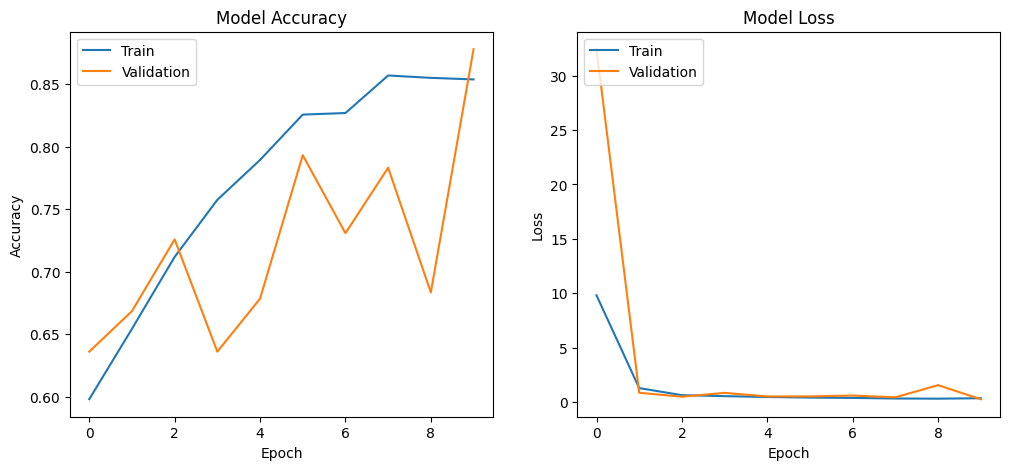

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()